In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('housing.csv')


In [4]:
df.shape

(20640, 10)

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

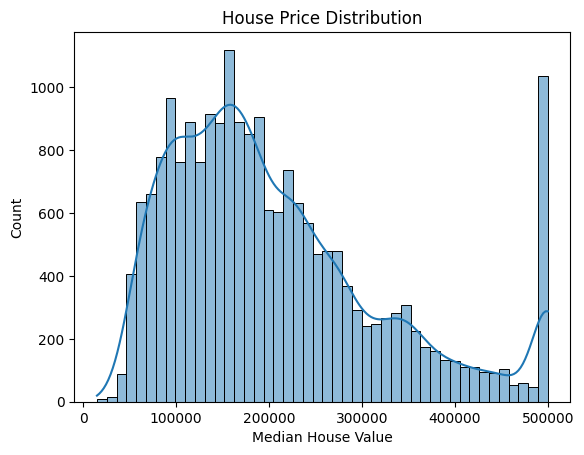

In [9]:
sns.histplot(df['median_house_value'], kde=True)
plt.title('House Price Distribution')
plt.xlabel('Median House Value')
plt.show()

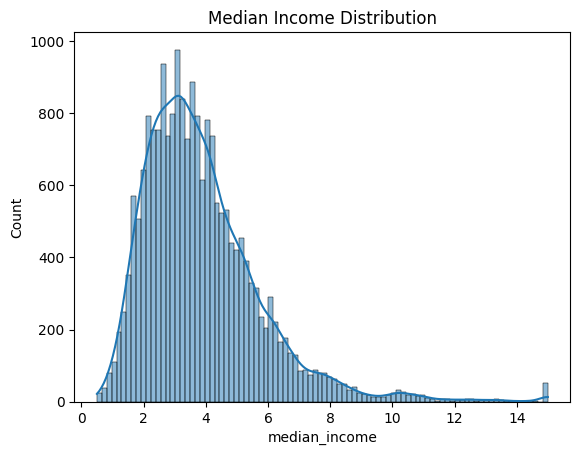

In [10]:
sns.histplot(df['median_income'], kde=True)
plt.title('Median Income Distribution')
plt.show()

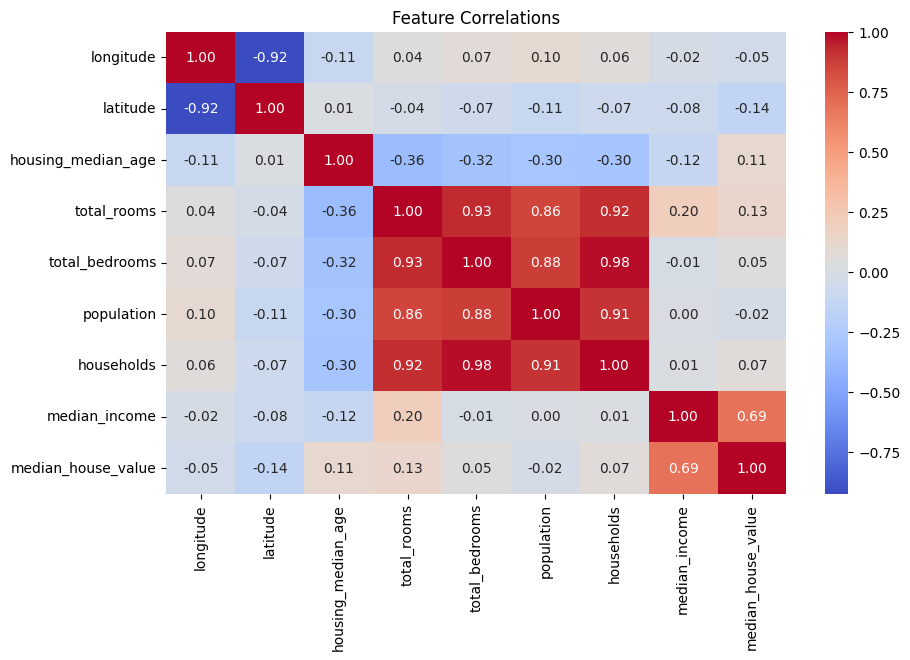

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

In [12]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [13]:
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

In [14]:
df = df[df['median_house_value'] < 500001]
print(df.shape)

(19675, 10)


In [15]:
df = pd.get_dummies(df, columns=['ocean_proximity'])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [16]:
df.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

In [17]:
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)
df.head()

KeyError: "None of [Index(['ocean_proximity'], dtype='object')] are in the [columns]"

In [18]:
# get the ocean_proximity columns and convert to int
ocean_cols = [col for col in df.columns if col.startswith('ocean_proximity')]
df[ocean_cols] = df[ocean_cols].astype(int)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [19]:
# Rooms per household — more useful than total rooms
df['rooms_per_household'] = df['total_rooms'] / df['households']

# Bedrooms per room — ratio of bedrooms to total rooms
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

# Population per household — how crowded is the block
df['population_per_household'] = df['population'] / df['households']

In [20]:
df = df.drop(columns=['total_rooms', 'total_bedrooms', 'population', 'households'])

In [21]:
df.head()
df.shape

(19675, 13)

In [22]:
df.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,8.3252,452600.0,0,0,0,1,0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,8.3014,358500.0,0,0,0,1,0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,7.2574,352100.0,0,0,0,1,0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,5.6431,341300.0,0,0,0,1,0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,3.8462,342200.0,0,0,0,1,0,6.281853,0.172096,2.181467


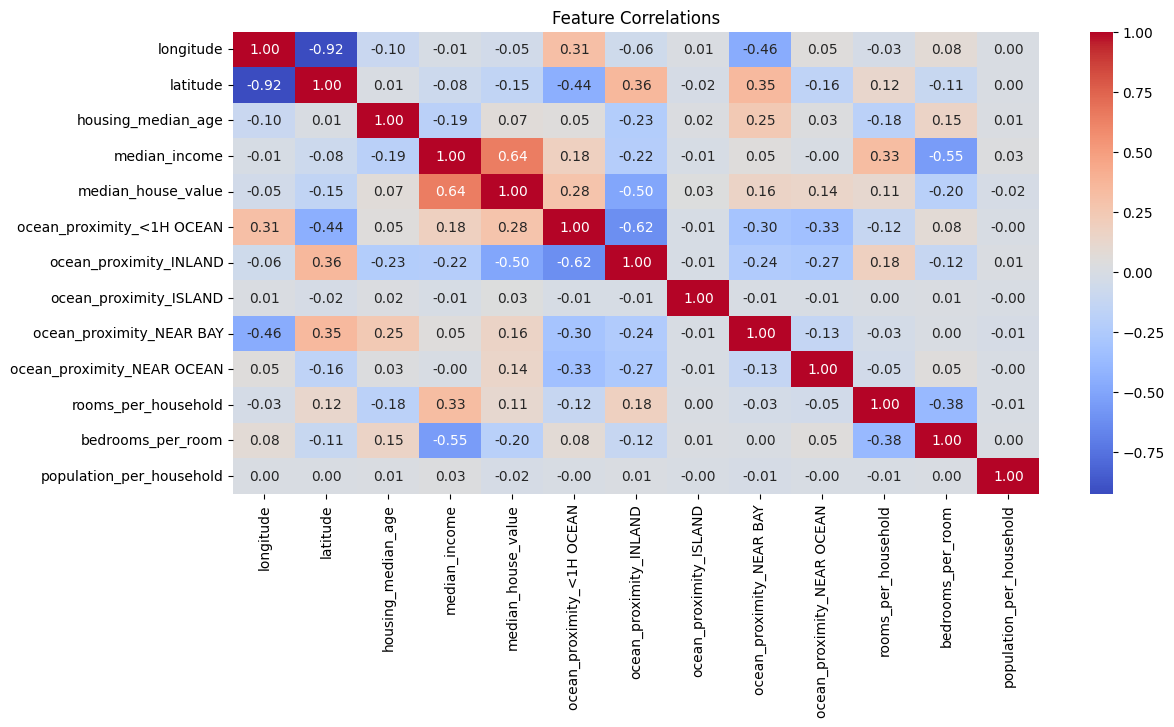

In [23]:
plt.figure(figsize=(13, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

In [24]:
# Separate features and target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# First split off 20% for test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split remaining 80% into 75/25 → gives 60% train, 20% CV
X_train, X_cv, y_train, y_cv = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

print(f"Train:  {X_train.shape}")
print(f"CV:     {X_cv.shape}")
print(f"Test:   {X_test.shape}")

Train:  (11805, 12)
CV:     (3935, 12)
Test:   (3935, 12)


In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_cv    = scaler.transform(X_cv)
X_test  = scaler.transform(X_test)

print("Scaling done")

Scaling done


In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [27]:
y_pred_cv = model.predict(X_cv)

mse = mean_squared_error(y_cv, y_pred_cv)
rmse = np.sqrt(mse)
r2 = r2_score(y_cv, y_pred_cv)

print(f"RMSE: {rmse:,.0f}")
print(f"R²:   {r2:.4f}")

RMSE: 63,242
R²:   0.5878


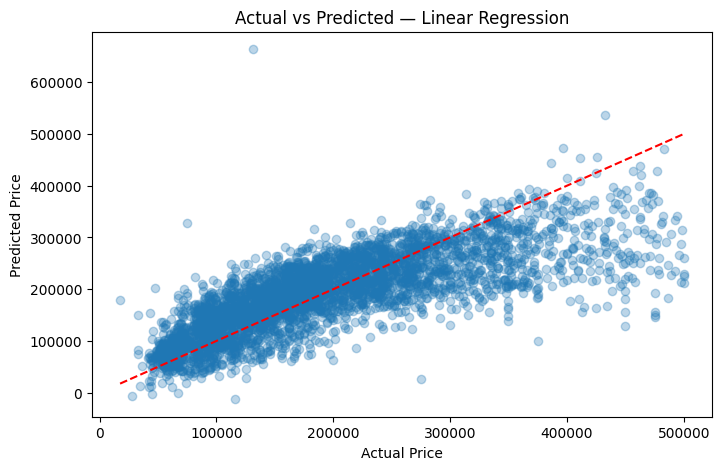

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(y_cv, y_pred_cv, alpha=0.3)
plt.plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted — Linear Regression')
plt.show()

In [32]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
poly.fit(X_train)
X_cv_poly = poly.transform(X_cv)
print(poly.get_feature_names_out())
print(f"Total features: {poly.n_output_features_}")

['1' 'x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x9' 'x10' 'x11' 'x0^2'
 'x0 x1' 'x0 x2' 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x0 x8' 'x0 x9'
 'x0 x10' 'x0 x11' 'x1^2' 'x1 x2' 'x1 x3' 'x1 x4' 'x1 x5' 'x1 x6' 'x1 x7'
 'x1 x8' 'x1 x9' 'x1 x10' 'x1 x11' 'x2^2' 'x2 x3' 'x2 x4' 'x2 x5' 'x2 x6'
 'x2 x7' 'x2 x8' 'x2 x9' 'x2 x10' 'x2 x11' 'x3^2' 'x3 x4' 'x3 x5' 'x3 x6'
 'x3 x7' 'x3 x8' 'x3 x9' 'x3 x10' 'x3 x11' 'x4^2' 'x4 x5' 'x4 x6' 'x4 x7'
 'x4 x8' 'x4 x9' 'x4 x10' 'x4 x11' 'x5^2' 'x5 x6' 'x5 x7' 'x5 x8' 'x5 x9'
 'x5 x10' 'x5 x11' 'x6^2' 'x6 x7' 'x6 x8' 'x6 x9' 'x6 x10' 'x6 x11' 'x7^2'
 'x7 x8' 'x7 x9' 'x7 x10' 'x7 x11' 'x8^2' 'x8 x9' 'x8 x10' 'x8 x11' 'x9^2'
 'x9 x10' 'x9 x11' 'x10^2' 'x10 x11' 'x11^2']
Total features: 91


In [33]:
poly_model = LinearRegression()
poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_cv_poly)
rmse_poly = np.sqrt(mean_squared_error(y_cv, y_pred_poly))
r2_poly = r2_score(y_cv, y_pred_poly)

print(f"Polynomial RMSE: {rmse_poly:,.0f}")
print(f"Polynomial R²:   {r2_poly:.4f}")

ValueError: X has 91 features, but LinearRegression is expecting 12 features as input.

In [34]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_cv_poly = poly.transform(X_cv)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)  # train on poly features, not X_train

y_pred_poly = poly_model.predict(X_cv_poly)
rmse_poly = np.sqrt(mean_squared_error(y_cv, y_pred_poly))
r2_poly = r2_score(y_cv, y_pred_poly)

print(f"Polynomial RMSE: {rmse_poly:,.0f}")
print(f"Polynomial R²:   {r2_poly:.4f}")

Polynomial RMSE: 86,950
Polynomial R²:   0.2209


In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_cv)

rmse_rf = np.sqrt(mean_squared_error(y_cv, y_pred_rf))
r2_rf = r2_score(y_cv, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:,.0f}")
print(f"Random Forest R²:   {r2_rf:.4f}")

Random Forest RMSE: 46,265
Random Forest R²:   0.7794


In [36]:
from sklearn.ensemble import GradientBoostingRegressor

xgb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_cv)

rmse_xgb = np.sqrt(mean_squared_error(y_cv, y_pred_xgb))
r2_xgb = r2_score(y_cv, y_pred_xgb)

print(f"Gradient Boosting RMSE: {rmse_xgb:,.0f}")
print(f"Gradient Boosting R²:   {r2_xgb:.4f}")

Gradient Boosting RMSE: 49,198
Gradient Boosting R²:   0.7506


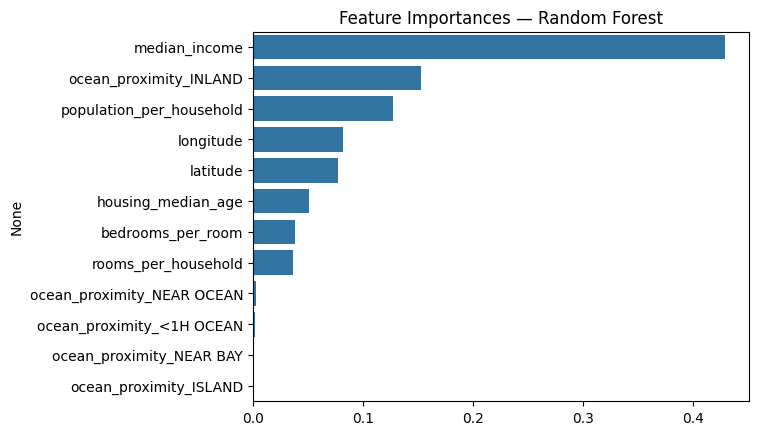

In [37]:
feature_names = df.drop('median_house_value', axis=1).columns
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importances — Random Forest')
plt.show()

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [39]:
best_model = grid_search.best_estimator_

y_pred_cv_tuned = best_model.predict(X_cv)

rmse_tuned = np.sqrt(mean_squared_error(y_cv, y_pred_cv_tuned))
r2_tuned = r2_score(y_cv, y_pred_cv_tuned)

print(f"Tuned RMSE: {rmse_tuned:,.0f}")
print(f"Tuned R²:   {r2_tuned:.4f}")


Tuned RMSE: 46,161
Tuned R²:   0.7804


In [40]:
y_pred_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"Final Test RMSE: {rmse_test:,.0f}")
print(f"Final Test R²:   {r2_test:.4f}")


Final Test RMSE: 47,122
Final Test R²:   0.7773
